In [ ]:
import pandas as pd 
import numpy as np
from tableone import TableOne
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import glob
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from sklearn.metrics import roc_curve, roc_auc_score

# data read-in

In [25]:
dat_path = "/Users/mlin2/Desktop/RabLab/tasks/concurrent/merged_dat_202603/"
clean_path = "/Users/mlin2/Desktop/RabLab/tasks/concurrent/cleaned_dat/"
dat_bl = pd.read_csv(clean_path + "merged_baseline_wDemo.csv")
clean_path = "/Users/mlin2/Desktop/RabLab/tasks/concurrent/cleaned_dat/"
ptau_cleaned = pd.read_csv(clean_path + "ptau_cleaned_20260330.csv")
tau_cleaned  = pd.read_csv(clean_path + "tau_cleaned_20260330.csv")
amy_df       = pd.read_csv(clean_path + "amy_cleaned_20260330.csv")
cdr_cleaned  = pd.read_csv(clean_path + "cdr_cleaned_20260330.csv")
moca_cleaned = pd.read_csv(clean_path + "moca_cleaned_20260330.csv")
# exclude antiamy
cdr_final = cdr_cleaned[cdr_cleaned.tx_started==0].drop(columns=['tx_start_date', 'tx_started'])
amy_final = amy_df[amy_df.tx_started==0].drop(columns=['tx_start_date', 'tx_started'])
tau_final = tau_cleaned[tau_cleaned.tx_started==0].drop(columns=['tx_start_date', 'tx_started'])
ptau_final = ptau_cleaned[ptau_cleaned.tx_started==0].drop(columns=['tx_start_date', 'tx_started'])
moca_final = moca_cleaned[moca_cleaned.tx_started==0].drop(columns=['tx_start_date','tx_started'])
#"ptau_merged_all_20260223_wROI.csv")#"ptau_merged_all_12_18_2025.csv")
#dat_long = pd.read_csv(dat_path + "ptau_merged_longitudinal_only_20260223_wROI.csv")#"ptau_merged_longitudinal_only_12_18_2025.csv")
#dat_bl = pd.read_csv(dat_path+"ptau_merged_baseline_20260223_wROI.csv")
#dat_bl = dat_bl[dat_bl.CohortAssgn.isin(["EOnonAD","EOAD"])]
#long_roi = pd.read_csv(dat_path + "tau_eoad_long_filtered_forROImodeling.csv")

# Cohort Assignment 

In [26]:
dat_bl = dat_bl.dropna(subset=["ptau217"])#"desikan_suvr",ptau217","centiloid_wcbl",
dat_bl.dx.value_counts()

dx
EOAD       376
EOnonAD    113
CN          95
Name: count, dtype: int64

In [27]:
dat_bl = dat_bl[dat_bl.dx != "CN"]
baseline_subj_list = dat_bl.subject_label.unique()
baseline_eoad_list = dat_bl[dat_bl.dx == "EOAD"].subject_label.unique()
baseline_eononad_list = dat_bl[dat_bl.dx == "EOnonAD"].subject_label.unique()
dat_bl.dx.value_counts()

dx
EOAD       376
EOnonAD    113
Name: count, dtype: int64

# follow up summary (EOAD)

In [31]:
cdr_long = cdr_final[cdr_final.subject_label.isin(baseline_eoad_list)]
amy_long = amy_final[amy_final.subject_label.isin(baseline_eoad_list)]
tau_long = tau_final[tau_final.subject_label.isin(baseline_eoad_list)]
ptau_long = ptau_final[ptau_final.subject_label.isin(baseline_eoad_list)]
moca_long = moca_final[moca_final.subject_label.isin(baseline_eoad_list)]

In [33]:
 
def summarize_and_keep_longitudinal(df, date_col, id_col="subject_label", label=""):
    df = df[df.subject_label.isin(baseline_eoad_list)].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    summary = (
        df.sort_values([id_col, date_col])
          .groupby(id_col)
          .agg(
              n_visits=(date_col, "nunique"),
              first_date=(date_col, "min"),
              last_date=(date_col, "max"),
          )
    )
    summary["followup_years"] = (summary["last_date"] - summary["first_date"]).dt.days / 365.25

    long_ids = summary.index[summary["n_visits"] >= 2]
    followup_vals = summary.loc[long_ids, "followup_years"]

    n_subjects = len(long_ids)
    df_long = df[df[id_col].isin(long_ids)].copy()
    n_records = len(df_long)
    mean_followup = followup_vals.mean()
    std_followup = followup_vals.std()
    print(f"{label} longitudinal records: {n_records}")
    print(f"{label} longitudinal subjects (>=2 visits): {n_subjects}")
    print(f"{label} follow-up (years): {mean_followup:.1f}±{std_followup:.1f}")
    return df_long, summary

ptau_eoad, ptau_summary = summarize_and_keep_longitudinal(
    ptau_long, date_col="ptau_date", label="ptau217"
)

cdr_eoad, cdr_summary = summarize_and_keep_longitudinal(
    cdr_long, date_col="cdr_date", label="CDR"
)

amy_eoad, amy_summary = summarize_and_keep_longitudinal(
    amy_long, date_col="amy_date", label="Amyloid PET"
)

tau_eoad, tau_summary = summarize_and_keep_longitudinal(
    tau_long, date_col="tau_date", label="Tau PET"
)

moca_eoad, moca_summary = summarize_and_keep_longitudinal(
    moca_long, date_col="moca_date", label="MOCA"
)

ptau217 longitudinal records: 591
ptau217 longitudinal subjects (>=2 visits): 221
ptau217 follow-up (years): 2.1±1.0
CDR longitudinal records: 784
CDR longitudinal subjects (>=2 visits): 267
CDR follow-up (years): 2.4±1.3
Amyloid PET longitudinal records: 659
Amyloid PET longitudinal subjects (>=2 visits): 242
Amyloid PET follow-up (years): 2.1±0.9
Tau PET longitudinal records: 649
Tau PET longitudinal subjects (>=2 visits): 241
Tau PET follow-up (years): 2.1±1.0
MOCA longitudinal records: 680
MOCA longitudinal subjects (>=2 visits): 233
MOCA follow-up (years): 2.4±1.2


# Table One (between EOAD and EOnonAD)

In [34]:
dat_bl['apoe4_status']=dat_bl['apoe4_alleles'].replace({0: "Non-Carriers", 1: "Heterozygous", 2: "Homozygous"}) 
dat_bl.apoe4_status.value_counts()

apoe4_status
Non-Carriers    234
Heterozygous    176
Homozygous       61
Name: count, dtype: int64

In [35]:
 # -----------------------------
# CONFIG
# -----------------------------
GROUP_COL = "dx"

# Variables (as in your message)
CONT_VARS = [
    "ptau217",
    "centiloid_wcbl",
    "age_at_pet",
    "years_education",
    "mmse_baseline",
    "cdrsb",
    "meta_temporal_suvr",
    "baseline_moca",
   # "mtl_no_hippocampus_FTP_SUVR",
   # "basolateral_temporal_FTP_SUVR",
   # "temporoparietal_FTP_SUVR",
    "desikan_suvr",
    #'CenTauRz_Universal', 
    #'CenTauRz_MetaTemporal', 
    #'CenTauRz_MesialTemporal', 
    #'CenTauRz_TemporoParietal', 
    #'CenTauRz_Frontal' 
]

CAT_VARS = [
    "sex",
    #"race",
    "ethnicity",
    "apoe4_status",
    "clinical_severity_baseline",
    "cdr_global",
]

# labels 
LABELS = {
    "pTau217.Conc..pg.mL.": "Plasma p-tau217 (pg/mL)",
    "Centiloids_wcbl": "[18F]Florbetaben PET Centiloids",
    "age_at_pet": "Age",
    "sex": "Sex",
    #"race": "Race",
    "ethnicity": "Ethnicity",
    "years_education": "Education (years)",
    "apoe4_status": "APOE4 Status",
    "clinical_severity_baseline": "Diagnosis",
    "mmse": "MMSE",
    "cdr_global": "CDR-Global",
    "cdrsb": "CDR-SB",
    "baseline_moca":"MOCA",
    "meta_temporal_suvr": "[18F]Flortaucipir PET SUVR (Meta-temporal)",
    #"mtl_no_hippocampus_FTP_SUVR": "[18F]Flortaucipir PET SUVR (MTL no hippocampus)",
    #"basolateral_temporal_FTP_SUVR": "[18F]Flortaucipir PET SUVR (Basolateral temporal)",
    #"temporoparietal_FTP_SUVR": "[18F]Flortaucipir PET SUVR (Temporoparietal)",
    "desikn_suvr": "[18F]Flortaucipir PET SUVR (Cortical DK)"
} 

t1 = dat_bl.copy()
for col in CAT_VARS:
    t1[col] = t1[col].replace(["None", "none", ""], np.nan)
    t1[col] = t1[col].astype("category")


TableOne(
    data=t1,
    columns=CAT_VARS + CONT_VARS,
    categorical=CAT_VARS,
    groupby="dx_ptau",
    rename=LABELS,
    pval=True,              
    nonnormal=["ptau217"],
    missing=True
)


Grouped by dx_ptau                                                     
                                                                                     Missing        Overall           EOAD        EOnonAD P-Value
n                                                                                                       489            376            113        
Sex, n (%)                                            Female                                     248 (50.7)     202 (53.7)      46 (40.7)   0.020
                                                      Male                                       241 (49.3)     174 (46.3)      67 (59.3)        
Ethnicity, n (%)                                      Hispanic/Latino                              21 (4.3)       10 (2.7)       11 (9.7)   0.003
                                                      Non-Hispanic/Latino                        468 (95.7)     366 (97.3)     102 (90.3)        
APOE4 Status, n (%)                                   Heterozygous                               176 (36.0)     141 (37.5)      35 (31.0)  <0.001
                                                      Homozygous                                  61 (12.5)      59 (15.7)        2 (1.8)        
                                                      Non-Carriers                               234 (47.9)     161 (42.8)      73 (64.6)        
                                                      None                                         18 (3.7)       15 (4.0)        3 (2.7)        
Diagnosis, n (%)                                      Dementia                                   314 (64.2)     272 (72.3)      42 (37.2)  <0.001
                                                      MCI                                        163 (33.3)      95 (25.3)      68 (60.2)        
                                                      None                                         12 (2.5)        9 (2.4)        3 (2.7)        
CDR-Global, n (%)                                     0.0                                          10 (2.0)        5 (1.3)        5 (4.4)  <0.001
                                                      0.5                                        293 (59.9)     207 (55.1)      86 (76.1)        
                                                      1.0                                        167 (34.2)     149 (39.6)      18 (15.9)        
                                                      2.0                                           1 (0.2)        1 (0.3)        0 (0.0)        
                                                      None                                         18 (3.7)       14 (3.7)        4 (3.5)        
ptau217, median [Q1,Q3]                                                                    0  1.3 [0.7,1.8]  1.5 [1.1,2.0]  0.3 [0.2,0.4]  <0.001
centiloid_wcbl, mean (SD)                                                                  8    79.9 (48.9)   103.2 (27.6)     3.4 (10.0)  <0.001
Age, mean (SD)                                                                            17     59.0 (4.6)     59.2 (4.0)     58.3 (6.3)   0.143
Education (years), mean (SD)                                                               0     15.6 (2.5)     15.6 (2.4)     15.7 (2.7)   0.810
mmse_baseline, mean (SD)                                                                  13     22.4 (5.4)     21.3 (5.4)     26.0 (3.5)  <0.001
CDR-SB, mean (SD)                                                                         18      3.6 (1.9)      3.9 (1.9)      2.6 (1.8)  <0.001
[18F]Flortaucipir PET SUVR (Meta-temporal), mean (SD)                                     17      2.0 (0.6)      2.2 (0.5)      1.2 (0.3)  <0.001
MOCA, mean (SD)                                                                           78     16.7 (6.4)     15.3 (6.2)     21.5 (4.8)  <0.001
desikan_suvr, mean (SD)                                                                   17      1.7 (0.5)      1.9 (0.5)      1.1 

# Distribution of ptau 

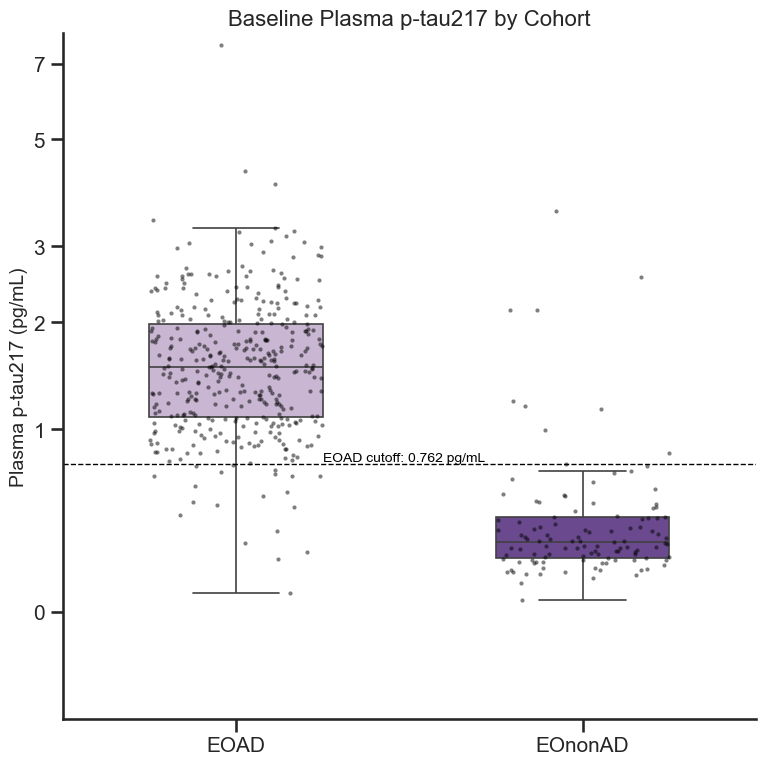

In [36]:
 
from matplotlib.ticker import FuncFormatter

PTAU_COL  = "ptau217"
GROUP_COL = "dx"

sns.set_theme(style="white", context="talk")
palette = sns.color_palette("colorblind", 2)

fig, ax = plt.subplots(figsize=(8, 8))

sns.boxplot(
    data=dat_bl,
    x=GROUP_COL,
    y=PTAU_COL,
    palette=sns.color_palette("Paired")[8:],
    width=0.5,
    linewidth=1.2,
    showfliers=False,
    ax=ax
)

sns.stripplot(
    data=dat_bl,
    x=GROUP_COL,
    y=PTAU_COL,
    color="black",
    alpha=0.5,
    size=3,
    jitter=0.25,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Plasma p-tau217 (pg/mL)", fontsize=14)
ax.set_title("Baseline Plasma p-tau217 by Cohort", fontsize=16)

# --- key change: log1p-like axis (works with zeros) ---
ax.set_yscale("function", functions=(np.log1p, np.expm1))

# ticks displayed in ORIGINAL units (choose what makes sense for your data)
ticks = [0, 1, 2, 3, 5, 7]
ax.set_yticks(ticks)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:g}"))
ax.tick_params(axis='both', which='major', labelsize=15, bottom=True, top=False, left=True, right=False, labelbottom=True, labelleft=True)
plt.axhline(0.751, color="black", linestyle="--", linewidth=1)
#plt.axhline(0.470, color="blue", linestyle="--", linewidth=1)
ax.text(0.25, 0.77, "EOAD cutoff: 0.762 pg/mL", color="black", fontsize=10)
#ax.text(0.25, 0.50, "NCRAD cutoff: 0.470 pg/mL", color="blue", fontsize=10)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

In [44]:
dat_bl.loc[dat_bl[PTAU_COL] == dat_bl[PTAU_COL].max()]

,subject_label,subject_baseline_date,baseline_year,ptau217,ptau_date,dx_ptau,baseline_date_ptau,is_baseline_ptau,baseline_ptau217,day_to_baseline_ptau,...,is_baseline_moca,baseline_moca,day_to_baseline_moca,record_year_moca,abs_diff_days_moca,dx,dob,age_at_ptau,apoe4_status,ptau_used
537,LDS3600565,2022-11-23,2022,7.592173,2023-02-14,EOAD,2023-02-14,1.0,NaN,0.0,...,1.0,14.0,0.0,2022.0,NaN,EOAD,1969-08-25,53.472964,Non-Carriers,2.027118


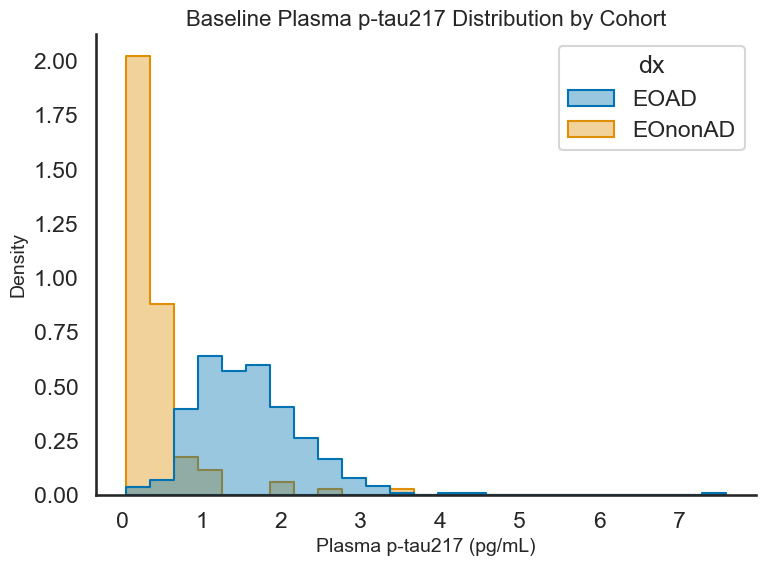

In [38]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=dat_bl,
    x=PTAU_COL,
    hue=GROUP_COL,
    palette=palette,
    element="step",
    stat="density",
    common_norm=False,
    bins=25,
    alpha=0.4
)

plt.xlabel("Plasma p-tau217 (pg/mL)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.title("Baseline Plasma p-tau217 Distribution by Cohort", fontsize=16)

sns.despine()
plt.tight_layout()
plt.show()

# Diagnostic performance of p-tau217 in Cognitive Impaired group 

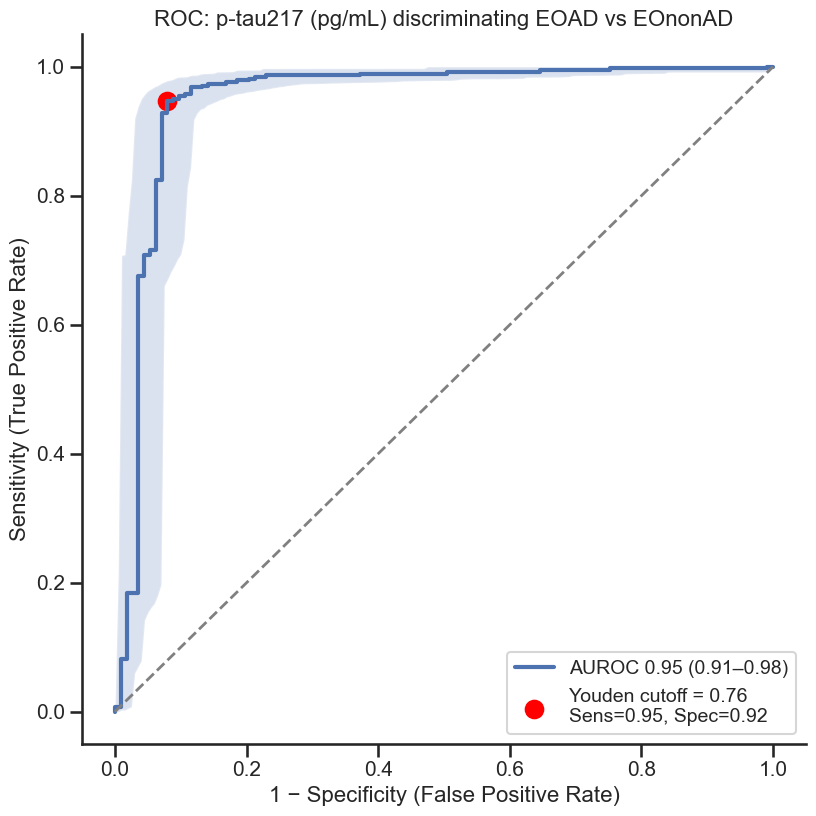

N=489  (EOAD=376, EOnonAD=113)
AUC = 0.95 (DeLong 95% CI 0.91–0.97)
Bootstrap AUC 95% CI 0.91–0.98
Youden cutoff = 0.762
Sensitivity = 0.95
Specificity = 0.92


In [55]:

# ----------------------------
# CONFIG
# ----------------------------
GROUP_COL = "dx"
POS_LABEL = "EOAD"
NEG_LABEL = "EOnonAD"
PTAU_COL  = "ptau217"
LOG_PTAU = False
BOOTSTRAP_N = 2000
RNG_SEED = 1
BAND_ALPHA = 0.20   # lighter shade
LINEWIDTH = 3

# ----------------------------
# DeLong AUC CI 
# ----------------------------
def _compute_midrank(x: np.ndarray) -> np.ndarray:
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    out = np.empty(N, dtype=float)
    out[J] = T
    return out

def _fast_delong(pred_sorted: np.ndarray, n_pos: int):
    m = n_pos
    n = pred_sorted.shape[1] - m
    pos = pred_sorted[:, :m]
    neg = pred_sorted[:, m:]

    k = pred_sorted.shape[0]
    tx = np.empty((k, m), dtype=float)
    ty = np.empty((k, n), dtype=float)
    tz = np.empty((k, m + n), dtype=float)

    for r in range(k):
        tx[r] = _compute_midrank(pos[r])
        ty[r] = _compute_midrank(neg[r])
        tz[r] = _compute_midrank(pred_sorted[r])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.atleast_2d(np.cov(v01))
    sy = np.atleast_2d(np.cov(v10))
    delong_cov = sx / m + sy / n
    return aucs, delong_cov

def delong_auc_ci(y_true: np.ndarray, y_score: np.ndarray, alpha: float = 0.05):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]

    n_pos = int(y_true.sum())
    if n_pos == 0 or n_pos == len(y_true):
        raise ValueError("Need both positive and negative samples for ROC/AUC.")

    pos_idx = y_true == 1
    neg_idx = ~pos_idx
    y_score_sorted = np.concatenate([y_score[pos_idx], y_score[neg_idx]])
    pred_sorted = y_score_sorted[np.newaxis, :]

    aucs, cov = _fast_delong(pred_sorted, n_pos)
    auc = float(aucs[0])
    var = float(cov[0, 0])
    se = np.sqrt(max(var, 0.0))

    z = 1.96
    lower = auc - z * se
    upper = auc + z * se
    return auc, max(0.0, lower), min(1.0, upper)

def bootstrap_roc_band(y_true, y_score, n_boot=2000, grid=None, seed=1):
    """
    Returns:
      grid_fpr, tpr_lo, tpr_hi, auc_lo, auc_hi
    Bootstrap resamples subjects with replacement, recomputes ROC and AUC.
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if grid is None:
        grid = np.linspace(0, 1, 201)

    n = len(y_true)
    idx = np.arange(n)

    tprs = []
    aucs = []

    for _ in range(n_boot):
        samp = rng.choice(idx, size=n, replace=True)

        if len(np.unique(y_true[samp])) < 2:
            continue

        fpr_b, tpr_b, _ = roc_curve(y_true[samp], y_score[samp])
        aucs.append(roc_auc_score(y_true[samp], y_score[samp]))

        # interpolate TPR on common FPR grid
        tpr_interp = np.interp(grid, fpr_b, tpr_b)
        tpr_interp[0] = 0.0
        tpr_interp[-1] = 1.0
        tprs.append(tpr_interp)

    tprs = np.asarray(tprs)
    aucs = np.asarray(aucs)

    tpr_lo = np.percentile(tprs, 2.5, axis=0)
    tpr_hi = np.percentile(tprs, 97.5, axis=0)

    auc_lo = np.percentile(aucs, 2.5)
    auc_hi = np.percentile(aucs, 97.5)

    return grid, tpr_lo, tpr_hi, auc_lo, auc_hi


if LOG_PTAU:
    dat_bl = dat_bl[dat_bl[PTAU_COL] > 0].copy()
    dat_bl["ptau_used"] = np.log(dat_bl[PTAU_COL].astype(float))
    x_label = "log(p-tau217)"
else:
    dat_bl["ptau_used"] = dat_bl[PTAU_COL].astype(float)
    x_label = "p-tau217 (pg/mL)"

y_true = (dat_bl[GROUP_COL] == POS_LABEL).astype(int).values
y_score = dat_bl["ptau_used"].values

# ----------------------------
# ROC, AUC, Youden
# ----------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

youden = tpr - fpr
best_idx = int(np.argmax(youden))
best_thr = float(thresholds[best_idx])
best_sens = float(tpr[best_idx])
best_spec = float(1 - fpr[best_idx])

# AUC 95% CI (DeLong) for display
auc_d, ci_lo, ci_hi = delong_auc_ci(y_true, y_score)

# Bootstrap ROC band + bootstrap AUC CI (optional to report too)
grid_fpr, tpr_lo, tpr_hi, aucb_lo, aucb_hi = bootstrap_roc_band(
    y_true, y_score, n_boot=BOOTSTRAP_N, seed=RNG_SEED
)

sns.set_theme(style="white",context="talk")  

fig, ax = plt.subplots(figsize=(8.5, 8.5))

# Bootstrap band (shaded)
ax.fill_between(
    grid_fpr, tpr_lo, tpr_hi,
    alpha=BAND_ALPHA
   # label=f"Bootstrap ROC 95% band (AUC 95% {aucb_lo:.3f}–{aucb_hi:.3f})"
)

# Main ROC
ax.plot(
    fpr, tpr,
    linewidth=LINEWIDTH,
    label=f"AUROC {auc:.2f} ({aucb_lo:.2f}–{aucb_hi:.2f})"
#DeLong 95% {ci_lo:.3f}–{ci_hi:.3f})"
)

# Chance line
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=2, color="gray")

# Youden point
ax.scatter(
    fpr[best_idx], tpr[best_idx],
    s=160, color="red",
    label=f"Youden cutoff = {best_thr:.2f}\nSens={best_sens:.2f}, Spec={best_spec:.2f}"
)

ax.set_xlabel("1 − Specificity (False Positive Rate)", fontsize=16)
ax.set_ylabel("Sensitivity (True Positive Rate)", fontsize=16)
ax.set_title(f"ROC: {x_label} discriminating {POS_LABEL} vs {NEG_LABEL}", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=15, bottom=True, top=False, left=True, right=False, labelbottom=True, labelleft=True)

ax.legend(fontsize=14, loc="lower right", frameon=True)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ----------------------------
# Print summary
# ----------------------------
print(f"N={len(dat_bl)}  ({POS_LABEL}={int(y_true.sum())}, {NEG_LABEL}={int((1-y_true).sum())})")
print(f"AUC = {auc:.2f} (DeLong 95% CI {ci_lo:.2f}–{ci_hi:.2f})")
print(f"Bootstrap AUC 95% CI {aucb_lo:.2f}–{aucb_hi:.2f}")
print(f"Youden cutoff = {best_thr:.3f}")
print(f"Sensitivity = {best_sens:.2f}")
print(f"Specificity = {best_spec:.2f}")

In [56]:
np.exp(-0.272)

0.7618542610898376

In [57]:
# additional calculate 
def sensitivity_specificity(y_true, y_score, threshold):
    """
    Compute sensitivity and specificity at a given threshold.

    Parameters
    ----------
    y_true : array-like (0/1)
    y_score : array-like (continuous biomarker)
    threshold : float

    Returns
    -------
    sens : sensitivity (TPR)
    spec : specificity (TNR)
    tp, fp, tn, fn : counts
    """

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    # predicted positive if >= threshold
    y_pred = (y_score >= threshold).astype(int)

    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sens, spec, tp, fp, tn, fn

In [58]:
sens, spec, tp, fp, tn, fn = sensitivity_specificity(y_true, y_score, 0.761)

print(f"Sensitivity = {sens:.2f}")
print(f"Specificity = {spec:.2f}")
print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")

Sensitivity = 0.95
Specificity = 0.92
TP=356, FP=9, TN=104, FN=20


In [59]:
sens, spec, tp, fp, tn, fn = sensitivity_specificity(y_true, y_score, 0.470)

print(f"Sensitivity = {sens:.2f}")
print(f"Specificity = {spec:.2f}")
print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")

Sensitivity = 0.98
Specificity = 0.78
TP=370, FP=25, TN=88, FN=6
